In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual aesthetics for our plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# 1. Load the cleaned data
url = "https://github.com/shalomali/ed-arrival-forecasting/raw/main/data/processed/ed_cleaned_base.csv"

df = pd.read_csv(url)

# 2. Re-cast Datetime and set it as the Index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')

# 3. Quick check for any missing hours
# (Pandas will resample to 1-hour frequency to see if any hours were skipped in the original data)
expected_hours = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
missing_hours = len(expected_hours) - len(df)
print(f"Total rows: {len(df)}")
print(f"Missing hourly gaps in timeline: {missing_hours}")

df.head()

Total rows: 31973
Missing hourly gaps in timeline: -14477


,Date,Hour,Arrivals
Datetime,,,
2014-01-01 00:00:00,2014-01-01,12 AM,2.0
2014-01-01 01:00:00,2014-01-01,1 AM,2.0
2014-01-01 02:00:00,2014-01-01,2 AM,3.0
2014-01-01 03:00:00,2014-01-01,3 AM,1.0
2014-01-01 04:00:00,2014-01-01,4 AM,1.0


In [3]:
# 1. Reset index temporarily to clean the duplicates
df = df.reset_index()

# 2. Sort by Arrivals ascending. This pushes the fake '0's to the top of any duplicates.
df = df.sort_values(by=['Datetime', 'Arrivals'])

# 3. Drop duplicate Datetimes, keeping the 'last' (the real, higher arrival number)
df = df.drop_duplicates(subset='Datetime', keep='last')

# 4. Set Datetime back to the index and re-sort the timeline chronologically
df = df.set_index('Datetime').sort_index()

# --- RE-RUN THE GAP CHECK ---
expected_hours = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h') # 'h' is deprecated in newer pandas, use 'h' or 'H'
missing_hours = len(expected_hours) - len(df)

print(f"CLEANED Total rows: {len(df)}")
print(f"CLEANED Missing hourly gaps: {missing_hours}")

CLEANED Total rows: 16344
CLEANED Missing hourly gaps: 1152


/tmp/ipykernel_7563/995488090.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_time_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')


First missing hour: 2014-01-02 05:00:00
Last missing hour: 2015-12-17 23:00:00
------------------------------


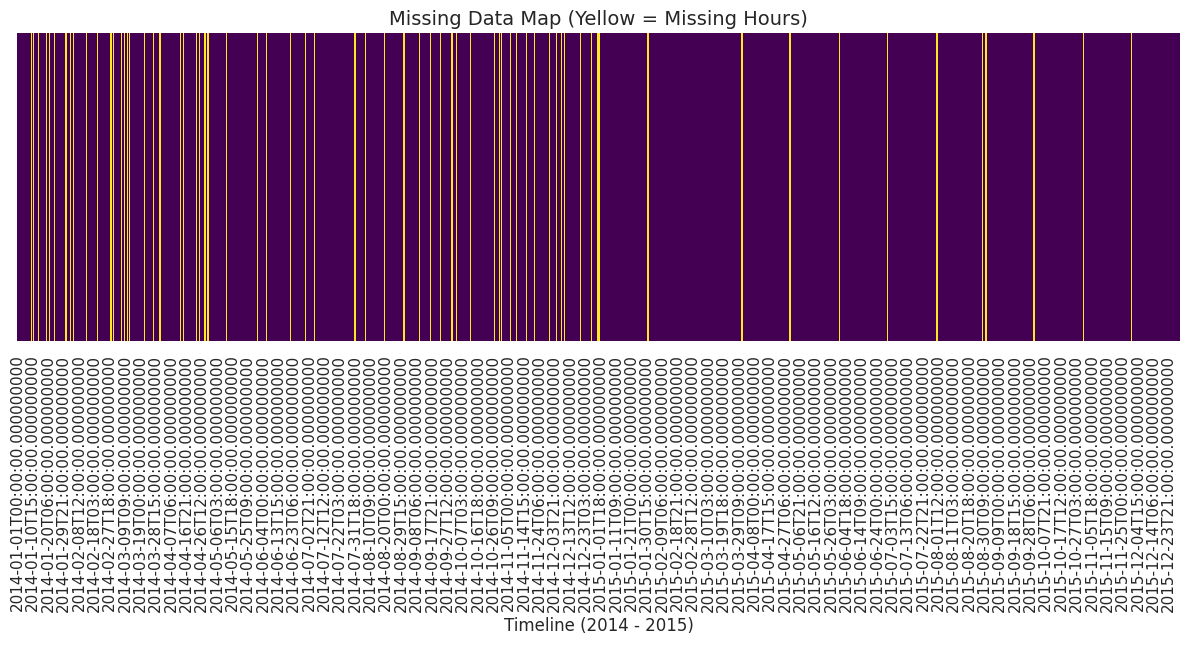

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a perfect, unbroken timeline from Jan 1, 2014 to Dec 31, 2015
full_time_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')

# 2. Re-index our dataframe to this perfect timeline.
# The 1,152 missing hours will now officially appear as 'NaN' (blanks)
df_full = df.reindex(full_time_range)
df_full.index.name = 'Datetime'

# 3. Find out exactly when the data went missing
missing_data = df_full[df_full['Arrivals'].isna()]
print(f"First missing hour: {missing_data.index.min()}")
print(f"Last missing hour: {missing_data.index.max()}")
print("-" * 30)

# 4. Create a visual map of the missing data
plt.figure(figsize=(15, 4))
sns.heatmap(df_full[['Arrivals']].isnull().T, cbar=False, cmap='viridis')
plt.title('Missing Data Map (Yellow = Missing Hours)', fontsize=14)
plt.xlabel('Timeline (2014 - 2015)')
plt.yticks([]) # Hide y-axis label for cleanliness
plt.show()

# Replace our working dataframe with the properly spaced one
df = df_full

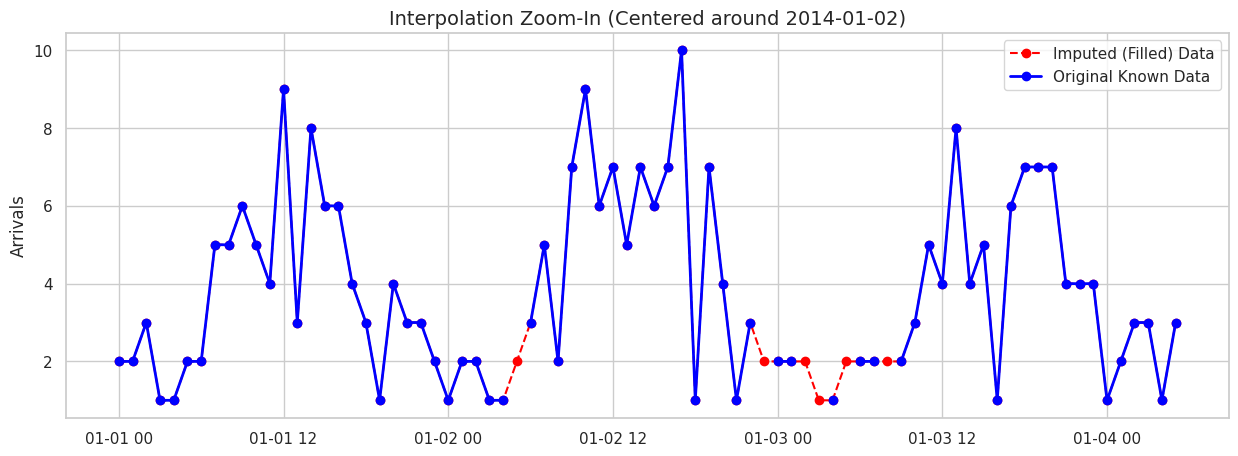

Remaining Missing Values: 0


In [6]:
# 1. Impute the missing values using linear interpolation
# (This essentially draws a straight line between the last known data point and the next known one)
df['Arrivals_Clean'] = df['Arrivals'].interpolate(method='linear')

# 2. Clean up the math: Arrivals must be whole numbers, and cannot be negative
df['Arrivals_Clean'] = df['Arrivals_Clean'].round().clip(lower=0)

# 3. Let's prove it worked by zooming in on the very first missing gap!
# Find the timestamp of the first missing data point
first_missing_date = df[df['Arrivals'].isna()].index[0]

# Create a 4-day window around that missing point to see the "patch"
window_start = first_missing_date - pd.Timedelta(days=2)
window_end = first_missing_date + pd.Timedelta(days=2)
df_zoom = df.loc[window_start:window_end]

# 4. Plot the comparison
plt.figure(figsize=(15, 5))
# Plot the newly imputed data in red
plt.plot(df_zoom.index, df_zoom['Arrivals_Clean'], color='red', linestyle='--', label='Imputed (Filled) Data', marker='o')
# Plot the original data in blue over top of it
plt.plot(df_zoom.index, df_zoom['Arrivals'], color='blue', linewidth=2, label='Original Known Data', marker='o')

plt.title(f'Interpolation Zoom-In (Centered around {first_missing_date.date()})', fontsize=14)
plt.ylabel('Arrivals')
plt.legend()
plt.show()

# 5. Once you are happy with the patch, overwrite the main column and drop the temp one
df['Arrivals'] = df['Arrivals_Clean']
df = df.drop(columns=['Arrivals_Clean'])

print(f"Remaining Missing Values: {df['Arrivals'].isna().sum()}")

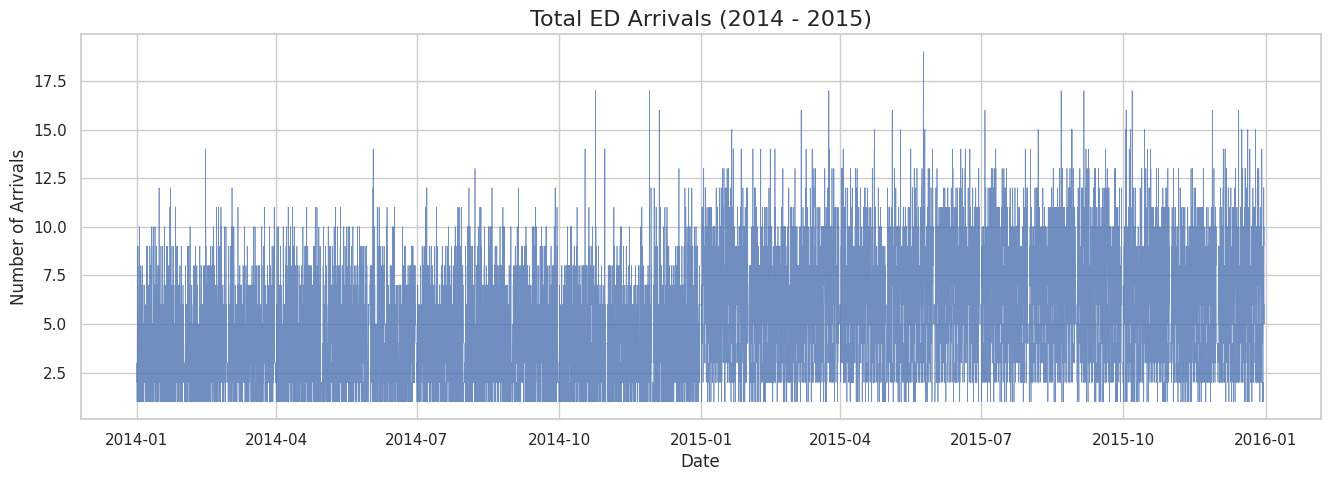

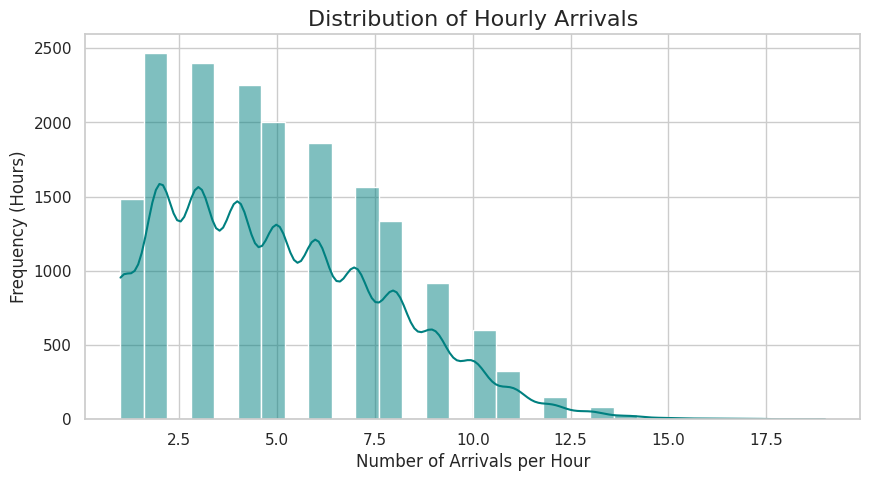

In [7]:
# --- PLOT 1: The Bird's-Eye View ---
plt.figure(figsize=(16, 5))
plt.plot(df.index, df['Arrivals'], linewidth=0.5, alpha=0.8)
plt.title('Total ED Arrivals (2014 - 2015)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Number of Arrivals')
plt.show()

# --- PLOT 2: The Distribution ---
plt.figure(figsize=(10, 5))
sns.histplot(df['Arrivals'], bins=30, kde=True, color='teal')
plt.title('Distribution of Hourly Arrivals', fontsize=16)
plt.xlabel('Number of Arrivals per Hour')
plt.ylabel('Frequency (Hours)')
plt.show()

/tmp/ipykernel_7563/214143665.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Hour', y='Arrivals', palette='Blues_d')


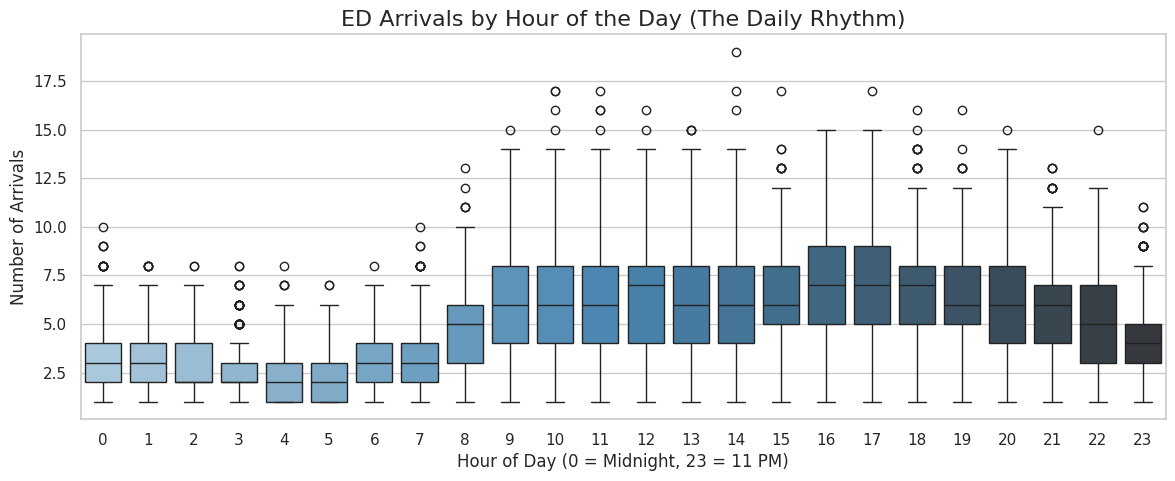

/tmp/ipykernel_7563/214143665.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='DayOfWeek', y='Arrivals', order=day_order, palette='Purples_d')


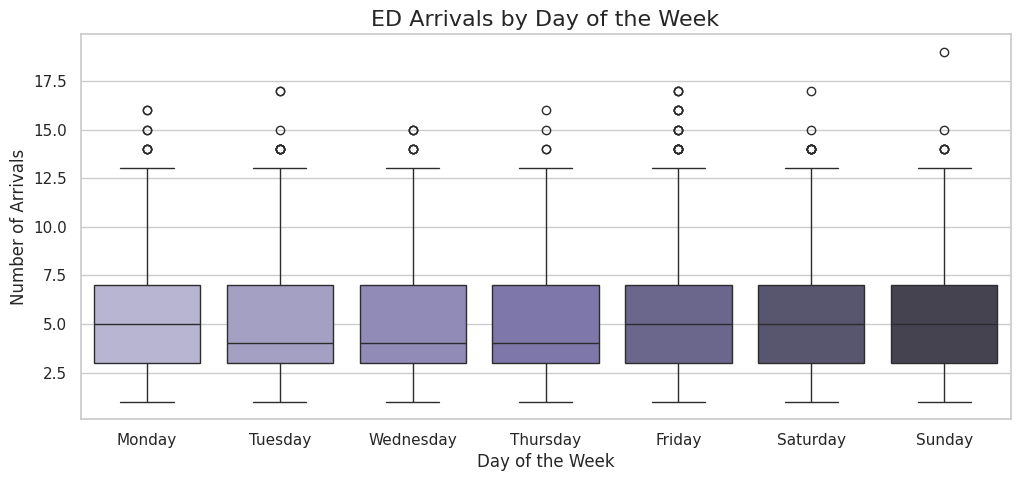

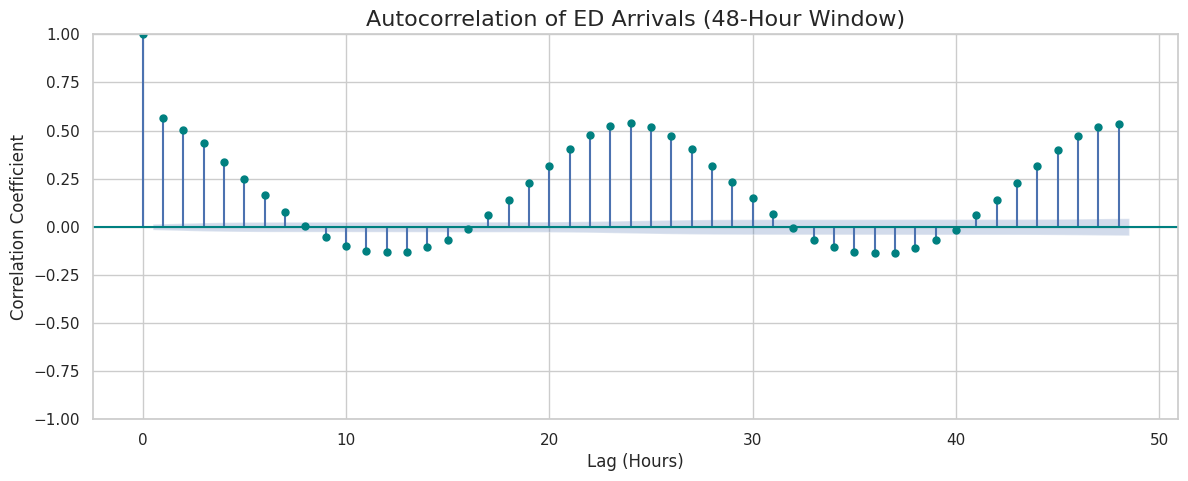

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# --- PREP: Temporarily extract time features for our plots ---
# (We will do this permanently in Notebook 3, but we need them now for plotting)
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.day_name()

# Sort days of the week for proper plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# --- PLOT 3: The Daily Rhythm (Arrivals by Hour) ---
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='Hour', y='Arrivals', palette='Blues_d')
plt.title('ED Arrivals by Hour of the Day (The Daily Rhythm)', fontsize=16)
plt.xlabel('Hour of Day (0 = Midnight, 23 = 11 PM)')
plt.ylabel('Number of Arrivals')
plt.show()

# --- PLOT 4: The Weekly Rhythm (Arrivals by Day of Week) ---
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='DayOfWeek', y='Arrivals', order=day_order, palette='Purples_d')
plt.title('ED Arrivals by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Arrivals')
plt.show()

# --- PLOT 5: Autocorrelation (ACF) ---
# This shows how strongly the current hour is correlated with previous hours
plt.figure(figsize=(14, 5))
plot_acf(df['Arrivals'], lags=48, ax=plt.gca(), color='teal') # Looking at a 48-hour window
plt.title('Autocorrelation of ED Arrivals (48-Hour Window)', fontsize=16)
plt.xlabel('Lag (Hours)')
plt.ylabel('Correlation Coefficient')
plt.show()

# Clean up our temporary columns before saving
df = df.drop(columns=['Hour', 'DayOfWeek'])

In [9]:
# Save the final, unbroken, clean dataset for Feature Engineering!
df.to_csv('ed_imputed_ready_for_features.csv')